## Module_3: Fibrosis

## Team Members:
Hayden Rue and Amelia Luongo

## Project Title:
Using Interpolation to Perform Fibrotic Analysis in the Lungs of Bleomycin-Induced Mice



## Project Goal:
This project seeks to determine the extent of fibrosis in the lungs of bleomycin-induced mice through interpolation by creating an algorithm to count the white pixels from 6 images at different depths throughout the lung and analyze and compare the errors associated with the linear, quadratic, and cubic forms of interpolation to recommend the best method.

## Disease Background: 
Idiopathic pulmonary fibrosis (IPF) is a chronic lung disease where the lungs exhibit progressive scarring, or fibrosis over time. Globally, IPF has a prevalence of 37.0 per 100,000 and an incidence of 10.9 per 100,000. The disease is characterized by shortness of breath, fatigue, weight loss, and a persistent dry cough. It arises from recurring micro-injuries to the lung’s alveolar epithelium, which leads to scar tissue formation by fibroblasts and excessive accumulation of the extracellular matrix in the interstitial space. As a result, the gas exchange and compliance of the lungs is impaired, causing increased respiratory rates and breathing efforts. Treatment for IPF focuses on slowing the progression of the disease and managing symptoms. Some antifibrotic medications, oxygen therapy, and lung transplantation are standard methods used to improve patient quality of life. 

IPF is known to have many genetic and lifestyle risk factors. The heritability is ~ 32% due to the presence of nucleotide polymorphisms. Other factors such as smoking, excessive exposure to fibrotic dusts, dietary intake, and physical exercise may also contribute to IPF susceptibility and severity. 

https://www.sciencedirect.com/science/article/pii/S0002962926000996?__cf_chl_tk=y8PR9WsslHvn3IZO1BOFvitQg2AirBlhvHo8L940pHE-1775058849-1.0.1.1-DP4C5y1rNRUlr_fL.JYyRcuNC41AfMSPmbfA4gxYYOs

https://pmc.ncbi.nlm.nih.gov/articles/PMC3443459/ 

https://journal.chestnet.org/article/S0012-3692(23)00753-5/fulltext 

## Data-Set: 
Unpublished data for this project was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. 

The data was collected from the lungs of Bleomycin-induced mice. Bleomycin is an antibiotic isolated from the fungus Streptomyces verticillus that causes lung fibrosis. After the mice were treated with Bleomycin, they were humanely euthanized, and their lungs were harvested (upper, middle, and lower lobes). The lungs were fixed with paraformaldehyde for preservation, mounted in gel or wax, and sliced with a cryotome for examination on a glass microscope slide. The slide was immunostained using a fluorescent-labeled antibody targeted to bind to desmin. Desmin is a protein found in myofibroblasts and serves as a marker for fibrotic lesions in the lungs. The slides were then viewed in a microscope and digitally captured, resulting in 78 black and white images in the transverse plane of the lungs from 0 to 10,000 microns in depth. The white pixels in the images represent where desmin is present and hence, a fibrotic lesion whereas the black pixels represent healthy tissue.


## Data Analyis: 
*Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this Jupyter notebook can run your code to perform the analysis that you did, generate your figures, generate your .csv file, etc.). Show your graphs here, which should have proper labeles (e.g., x- and y-axes labels). Each graph you present should be thoroughly described by a caption so reader understands the data, why you are presenting it, and the main conclusion fromt the data.*

The following code analyzes a set of images to determine the percentage of white pixels in each. The white pixels represent fibrotic lesion in a fibrotic mouse lung, and the black pixels represent healthy lung tissue. The data is presented in a graph and saved as a csv file containing the image name, lung depth, and percent white pixels. 

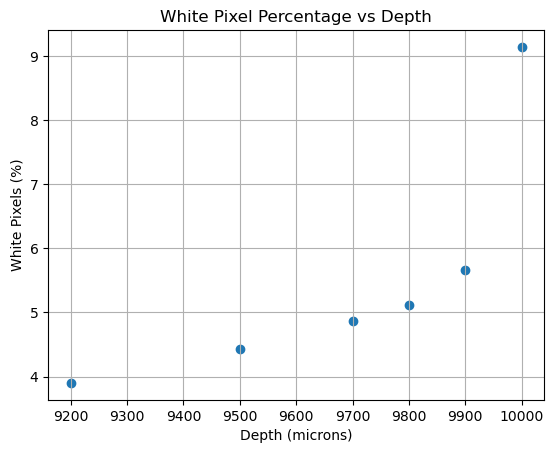

In [ ]:
from termcolor import colored
import cv2
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# import the file paths for the 6 images to analyze

filenames = [
    r"/Users/amelialuongo/Desktop/comp bme/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010136.jpg",
    r"/Users/amelialuongo/Desktop/comp bme/Module-3-Fibrosis/images/6 images/MASK_SK658 Slobe ch010068.jpg",
    r"/Users/amelialuongo/Desktop/comp bme/Module-3-Fibrosis/images/6 images/MASK_SK658 Slobe ch010098.jpg",
    r"/Users/amelialuongo/Desktop/comp bme/Module-3-Fibrosis/images/6 images/MASK_SK658 Slobe ch010118.jpg",
    r"/Users/amelialuongo/Desktop/comp bme/Module-3-Fibrosis/images/6 images/MASK_SK658 Slobe ch010135.jpg",
    r"/Users/amelialuongo/Desktop/comp bme/Module-3-Fibrosis/images/6 images/MASK_SK658 Slobe ch010104.jpg",
]

depths = [9200, 9800, 10000, 9900, 9500, 9700]


# IMAGE PROCESSING

data_rows = []



for i, (filename, depth) in enumerate(zip(filenames, depths)):
    img = cv2.imread(filename, 0)

    if img is None:
        print(colored(f"Error loading image: {filename}", "red"))
        continue

    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    total_pixels = binary.size
    white = np.count_nonzero(binary)
    black = total_pixels - white
    white_percent = 100 * white / total_pixels

    data_rows.append({
        'Filename': filename,
        'Depth': depth,
        'White percent': white_percent
    })


# SAVE CSV

df = pd.DataFrame(data_rows)
df.to_csv('Percent_White_Pixels.csv', index=False)


plt.figure()
plt.scatter(df["Depth"], df["White percent"])
plt.xlabel("Depth (microns)")
plt.ylabel("White Pixels (%)")
plt.title("White Pixel Percentage vs Depth")
plt.grid()
plt.show()



The next code does a linear interpolation of the percent white pixels at 9600 microns. The new estimated point is plotted against the given data on the graph below. 

The interpolated point is at the x-coordinate 9600.0 and y-coordinate 4.648387432098389.The estimated white pixel percent is 4.648387432098389.


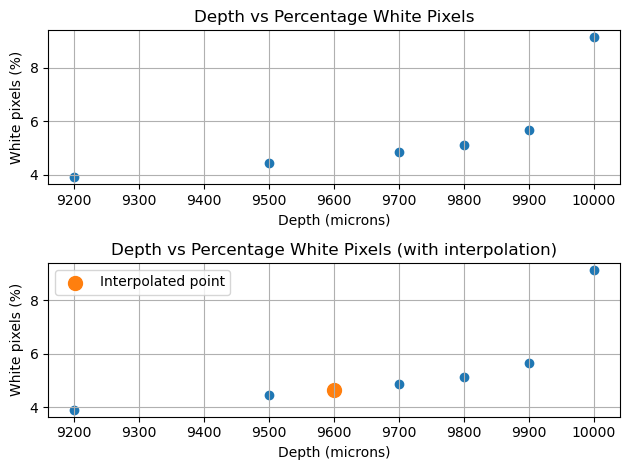

In [ ]:
interpolate_depth = float(input(colored(
    "Enter the depth at which you want to interpolate a point (in microns): ", "yellow")))

# Extract from DataFrame
x = df['Depth'].tolist()
y = df['White percent'].tolist()

# Sort data (REQUIRED for interp1d)
sorted_pairs = sorted(zip(x, y))
x, y = zip(*sorted_pairs)
x = list(x)
y = list(y)

# Interpolate
i = interp1d(x, y, kind='linear')
interpolate_point = float(i(interpolate_depth))

print(colored(
    f'The interpolated point is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.The estimated white pixel percent is {interpolate_point}.', "green"))

# Add interpolated point
depths_i = x + [interpolate_depth]
white_percents_i = y + [interpolate_point]


# PLOTTING

fig, axs = plt.subplots(2, 1)

# Original data
axs[0].scatter(x, y)
axs[0].set_title('Depth vs Percentage White Pixels')
axs[0].set_xlabel('Depth (microns)')
axs[0].set_ylabel('White pixels (%)')
axs[0].grid(True)

# With interpolated point
axs[1].scatter(x, y)
axs[1].scatter(interpolate_depth, interpolate_point, s=100, label='Interpolated point')
axs[1].set_title('Depth vs Percentage White Pixels (with interpolation)')
axs[1].set_xlabel('Depth (microns)')
axs[1].set_ylabel('White pixels (%)')
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()

The percent white pixels for the same depth (9600 microns) is interpolated using a quadratic function below. The new interpolation point is graphed against the given data. 

The interpolated point is at the x-coordinate 9600.0 and y-coordinate 4.630343679817256. The estimated white pixel percent is 4.630343679817256. 


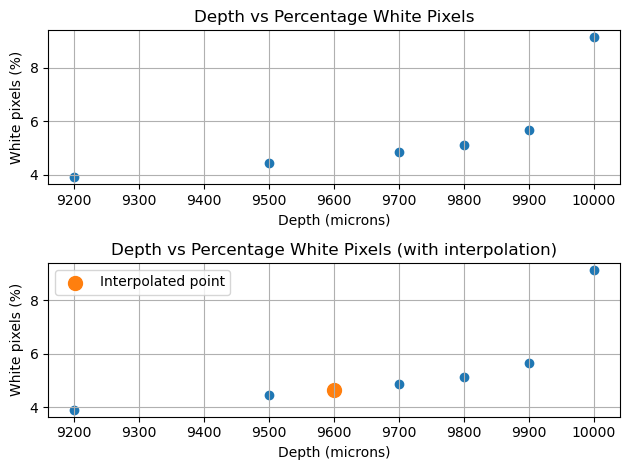

In [ ]:
interpolate_depth = float(input(colored(
    "Enter the depth at which you want to interpolate a point (in microns): ", "yellow")))

# Extract from DataFrame
x = df['Depth'].tolist()
y = df['White percent'].tolist()

# Sort data (REQUIRED for interp1d)
sorted_pairs = sorted(zip(x, y))
x, y = zip(*sorted_pairs)
x = list(x)
y = list(y)

# Interpolate
i = interp1d(x, y, kind='quadratic')
interpolate_point = float(i(interpolate_depth))

print(colored(
    f'The interpolated point is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}. The estimated white pixel percent is {interpolate_point}. ', "green"))

# Add interpolated point
depths_i = x + [interpolate_depth]
white_percents_i = y + [interpolate_point]


# PLOTTING

fig, axs = plt.subplots(2, 1)

# Original data
axs[0].scatter(x, y)
axs[0].set_title('Depth vs Percentage White Pixels')
axs[0].set_xlabel('Depth (microns)')
axs[0].set_ylabel('White pixels (%)')
axs[0].grid(True)

# With interpolated point
axs[1].scatter(x, y)
axs[1].scatter(interpolate_depth, interpolate_point, s=100, label='Interpolated point')
axs[1].set_title('Depth vs Percentage White Pixels (with interpolation)')
axs[1].set_xlabel('Depth (microns)')
axs[1].set_ylabel('White pixels (%)')
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()

The percent white pixels for the same depth (9600 microns) is interpolated using a cubic function below. The new interpolation point is graphed against the given data. 

The interpolated point is at the x-coordinate 9600.0 and y-coordinate 4.617617962628427.The estimated white pixel percent is 4.617617962628427.


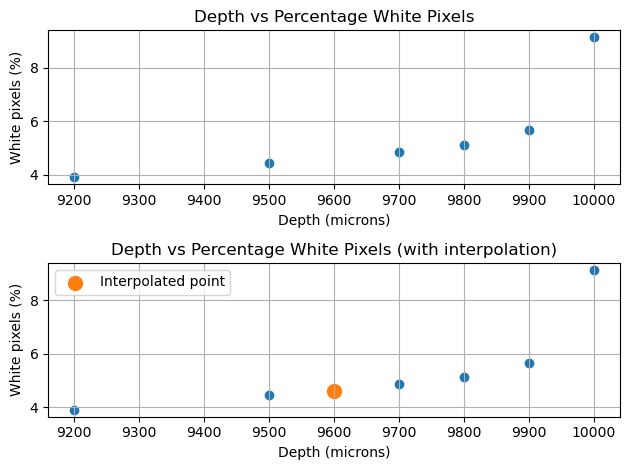

In [16]:
interpolate_depth = float(input(colored(
    "Enter the depth at which you want to interpolate a point (in microns): ", "yellow")))

# Extract from DataFrame
x = df['Depth'].tolist()
y = df['White percent'].tolist()

# Sort data (REQUIRED for interp1d)
sorted_pairs = sorted(zip(x, y))
x, y = zip(*sorted_pairs)
x = list(x)
y = list(y)

# Interpolate
i = interp1d(x, y, kind='cubic')
interpolate_point = float(i(interpolate_depth))

print(colored(
    f'The interpolated point is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.The estimated white pixel percent is {interpolate_point}.', "green"))

# Add interpolated point
depths_i = x + [interpolate_depth]
white_percents_i = y + [interpolate_point]


# PLOTTING

fig, axs = plt.subplots(2, 1)

# Original data
axs[0].scatter(x, y)
axs[0].set_title('Depth vs Percentage White Pixels')
axs[0].set_xlabel('Depth (microns)')
axs[0].set_ylabel('White pixels (%)')
axs[0].grid(True)

# With interpolated point
axs[1].scatter(x, y)
axs[1].scatter(interpolate_depth, interpolate_point, s=100, label='Interpolated point')
axs[1].set_title('Depth vs Percentage White Pixels (with interpolation)')
axs[1].set_xlabel('Depth (microns)')
axs[1].set_ylabel('White pixels (%)')
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()

The graph below compares all three interpolation methods by plotting their regression lines between the given data points. 

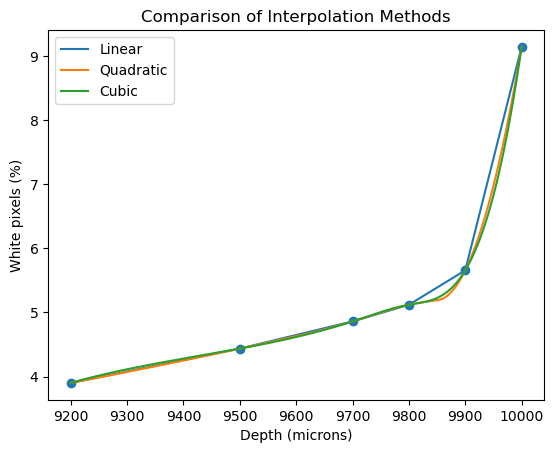

In [ ]:
# Create interpolation functions
linear = interp1d(x, y, kind='linear')
quadratic = interp1d(x, y, kind='quadratic')
cubic = interp1d(x, y, kind='cubic')

# plot all three regression lines
x_smooth = np.linspace(min(x), max(x), 200)

plt.plot(x_smooth, linear(x_smooth), label='Linear')
plt.plot(x_smooth, quadratic(x_smooth), label='Quadratic')
plt.plot(x_smooth, cubic(x_smooth), label='Cubic')
plt.scatter(x, y)

plt.legend()
plt.xlabel("Depth (microns)")
plt.ylabel("White pixels (%)")
plt.title("Comparison of Interpolation Methods")
plt.show()

## Verify and validate your analysis: 
*Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., by comparing your analysis to a published paper).*

The analysis is verified below by calculating the true percentage of white pixels using an image with a depth of 9600 microns. The percentage is compared to the estimated values from the linear, quadratic, and cubic interpolation functions. The percent error for each type of interpolation is summarized in a table. 


In [13]:
from termcolor import colored
import cv2
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# -----------------------------
# INPUT DATA
# -----------------------------
filenames = [
    r"/Users/amelialuongo/Desktop/comp bme/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010103.jpg",
]

depths = [9600]

# -----------------------------
# IMAGE PROCESSING
# -----------------------------
data_rows = []


for i, (filename, depth) in enumerate(zip(filenames, depths)):
    img = cv2.imread(filename, 0)

    if img is None:
        print(colored(f"Error loading image: {filename}", "red"))
        continue

    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    total_pixels = binary.size
    white = np.count_nonzero(binary)
    black = total_pixels - white
    white_percent = 100 * white / total_pixels

    data_rows.append({
        'Filename': filename,
        'Depth': depth,
        'White percent': white_percent
    })

    
    print(colored(f"White pixels: {white}", "white"))
    print(colored(f"Black pixels: {black}", "white"))

    print(colored(f"{white_percent:.2f}% White | Depth: {depth} microns\n", "yellow"))

White pixels: 193743
Black pixels: 4000561
4.62% White | Depth: 9600 microns



Percent Error For Each Interpolation Type:

| Name | Linear | Quadratic | Cubic |
|:-----:|:------:|:----:|:------:|
| Estimated White Pixel Percent | 4.648387432098389   | 4.630343679817256  | 4.617617962628427    |
| Percent Error| 0.614% | 0.224%  | 0.052% |

All three methods gave reasonable points with relatively low error. When plotted with the given data, they follow similar trends and fit well with the other points. Overall, we recommend using a cubic interpolation function for future interpolations. It had the lowest percent error at only 0.052%.

## Conclusions and Ethical Implications: 
*Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*Describe the limitations of your project. If you had more time to work on this, what would you do to explore further or refine your analysis?*

## References:
*You can use any format you like but provide the citations for facts that you referenced in this project notebook.*